# Deepweeds - MobileNetv3Small

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

tf.__version__

2025-07-05 06:39:13.207442: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-05 06:39:13.207593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-05 06:39:13.341016: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.15.0'

# Configurations

In [2]:
INFERENCE_DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 4
oversampling = 0 # How many times are we gonna over sample

## Subspace_Bottleneck_FCLayer Config
NUM_SPACES = 4 #Experiment 3
FINAL_FEAT_SIZE = 1024 #Mobilenet V3 Small - Feature Size

## Model Configurations
MODEL_NAME=f"MobileNetV3Small_KF{K_FOLD_INDEX+1}.keras"
IMG_SIZE=(224,224,3)

## Training Configurations
TRAIN_BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 16 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-7 ## Minimum Learning Rate for ReduceLROnPlateau Callback
##
USE_WARMUP = False
WARMUP_EPOCHS = 5
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCHS
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.3

##### After Base Model Freezing and Appending Subspace FC Layer. Training only FC Layer.
INIT_LR2 = 2e-6 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-4 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau

#### -- Optimizer
USE_ADAMW = '2.15' in tf.__version__
#########################################
isKaggle = 'kaggle' in os.getcwd()

if isKaggle:
    DATASET_PATH = "/kaggle/input/deepweeds"
    IMAGE_DATASET_PATH = "/kaggle/input/deepweeds/images" ## For Kaggle
    DATASET_OUTPUT_PATH = "/kaggle/working/deepweeds_9c" ## For Kaggle
else:
    try:
        DATASET_PATH = reganmaharjan_deepweeds_path
        DATASET_OUTPUT_PATH = '/content/dataset_9c' ## For GoogleColab
        IMAGE_DATASET_PATH = reganmaharjan_deepweeds_path + '/images' ## For GoogleColab
    except:
        DATASET_PATH = ''
        IMAGE_DATASET_PATH = '' ## Assign The Image Path
        DATASET_OUTPUT_PATH = '' ## Assign The path where the Images are to ogranized for Data Generator from Directory


isTPU = False
fixDatasetBatch = False ## if True: duplicates files randomly such that each batch contains same no.of files - Required when isTPU=True.

In [3]:
print("Tensorflow version " + tf.__version__)
if tf.config.list_logical_devices('TPU'):
    if isKaggle:
        # On TPU VMs use this line instead:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  ## if kaggle
    else:        
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver() ## if colab

    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)

    #---------
    strategy = tf.distribute.TPUStrategy(resolver)
    print('TPU available')
    isTPU = True
else: ### If GPU or CPU
    if tf.config.list_logical_devices('GPU'): 
        print('GPU available')
    else:
        print("Only CPU available")
       
    # For testing without a TPU use this line instead: 
    # strategy = tf.distribute.OneDeviceStrategy("/cpu:0")
    strategy = tf.distribute.MirroredStrategy()


print("REPLICAS: ", strategy.num_replicas_in_sync)
if isTPU:
    USE_ADAMW = False
    LR_REDUCTION_PATIENCE = 5
    ES_PATIENCE = 27
    print("Use ADAM with TPU")

Tensorflow version 2.15.0
GPU available
REPLICAS:  1


In [4]:
def seedEverything(seed=42, deterministic = False):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    tf.keras.utils.set_random_seed(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()
        
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        #tf.config.threading.set_inter_op_parallelism_threads(1)
        #tf.config.threading.set_intra_op_parallelism_threads(1)


seedEverything(SEED, USE_DETERMINISTIC)
tf.config.set_soft_device_placement(True)

In [5]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [6]:
try:
    data_info = pd.read_csv(f"{DATASET_PATH}/labels.csv") ## For Kaggle
except:
    data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [7]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [8]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [9]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [10]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 5 out of 5 folds
-------------------------------------------------



In [11]:
## Using Folds Used in The DeepWeeds Paper
try:
    train_data = pd.read_csv(f'{DATASET_PATH}/train_subset{K_FOLD_INDEX}.csv')
    valid_data = pd.read_csv(f'{DATASET_PATH}/val_subset{K_FOLD_INDEX}.csv')
    test_data = pd.read_csv(f'{DATASET_PATH}/test_subset{K_FOLD_INDEX}.csv')

except:
    train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
    valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
    test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab

train_data.rename(columns={"Label":"label"}, inplace=True)
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  676  638  619  613  637  606  645  610  5464 	Total: (10508, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  205  213  202  215  203  1821 	Total: (3503, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  212  206  204  212  201  214  203  1821 	Total: (3498, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [12]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0, oversampling_labels=[]):
    indices=[]
    if fixDatasetBatch or isTPU:
        batch = TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync
        size = data_info.shape[0]
        remainder = size % batch
        residue = batch - remainder
        rng = np.arange(size)
        np.random.shuffle(rng)
        indices = rng[:residue]
        
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)
            elif index in indices:
                sample_filename = os.path.join(target_path, f"last_batch_fix_{index}-"+filename)
                shutil.copy(source, sample_filename)
                
            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import math

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)

    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = [0.0 if math.isnan(v) else v for v in history['accuracy']]
    val_acc = [0.0 if math.isnan(v) else v for v in history['val_accuracy']]
    loss = [0.0 if math.isnan(v) else v for v in history['loss']]
    val_loss = [0.0 if math.isnan(v) else v for v in history['val_loss']]
    
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [14]:
if oversampling:
    print("Oversampling training set",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

input_dir = IMAGE_DATASET_PATH
base_dir = DATASET_OUTPUT_PATH

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

with strategy.scope(): 
    if isTPU:  
        train_generator = train_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        validation_generator = validation_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        test_generator = test_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        
    train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
    validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)
    test_generator = test_generator.prefetch(tf.data.AUTOTUNE)     

Found 10508 files belonging to 9 classes.
Found 3503 files belonging to 9 classes.
Found 3498 files belonging to 9 classes.


# Sample Images

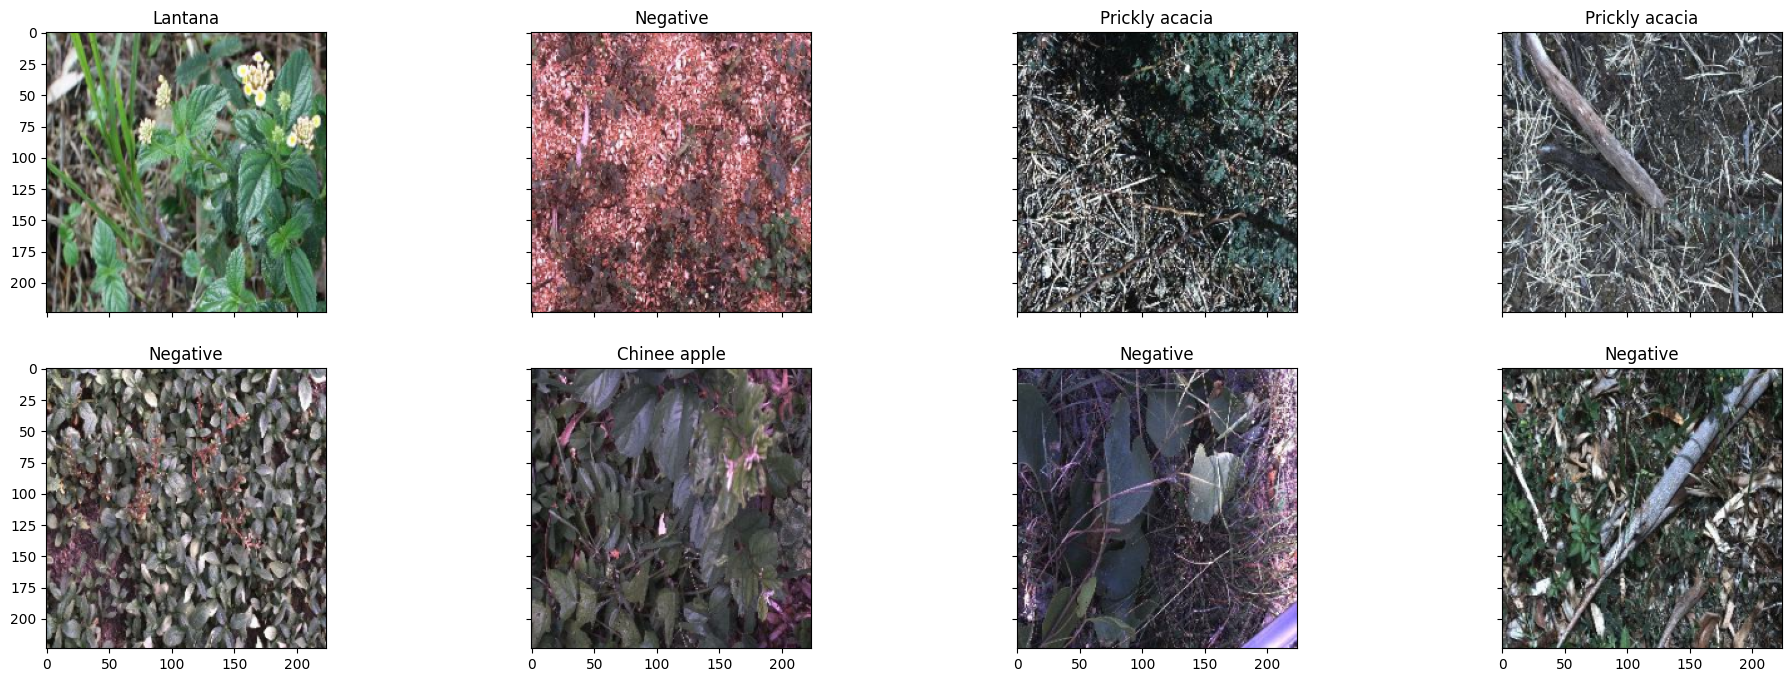

In [16]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [17]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax


def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

# Building MobileNet Model

In [18]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall

def augment(seed=42):
    augs = [] if isTPU else [layers.RandomRotation(0.5, seed=seed, name='RR_Rot'), 
                            layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
                            layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),] ## can't run with TPU
    
    aug_model = keras.Sequential([
        layers.Input(IMG_SIZE),
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        *augs,
        layers.GaussianNoise(0.01, seed=SEED, name='RR_GNoise'),
        # layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')
    aug_model.summary()
    
    return aug_model


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model


def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def MobilenetV3Base(img_size):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    mobilenet = MobileNetV3Small(input_shape=img_size, weights='imagenet', include_preprocessing=False)
    mobilenet.trainable = True

    base_index = 0
    for i in range(len(mobilenet.layers)):
        if('global_average_pooling2d' in mobilenet.layers[i].name):
            base_index = i
            break
            
    out_layer = mobilenet.layers[base_index-1]
    base_model =  keras.Model(inputs=mobilenet.layers[0].output, outputs=out_layer.output, name = mobilenet.name+"_base_")
    base_model.trainable = True
    
    pi0 = base_index+1 # pooler index start - #conv_layer
    pi1 = base_index+2 # pooler index end - # activation
    for i in range(base_index, len(mobilenet.layers)):
        if('dropout' in mobilenet.layers[i].name):
            pi1 = i
            break
    
    FCLayer = keras.Model(inputs=mobilenet.layers[pi0].input, outputs=mobilenet.layers[pi1].output, name="MobileNet-FCLayer")
    
    return base_model , FCLayer

def subSpaceBottleneckFCLayer(in_shape, n_spaces = 8, out_feat_size = 1024):
    final_out = out_feat_size // n_spaces
    interm_out = final_out*2
    
    bottleneck_layer = keras.Sequential([
        layers.Input(in_shape),
        layers.Reshape((n_spaces, -1), name="SubspaceFC_Reshape"),
        layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
        layers.Dense(interm_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Bottleneck_Expand"),
        layers.Dense(final_out, use_bias=False, kernel_regularizer=keras.regularizers.L1L2(0.01,0.01), name="SubspaceFC_Bottleneck_Compress"),
        layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
    ], name='Subspace_Bottleneck_FCLayer')
    bottleneck_layer.summary()
    
    return bottleneck_layer
    

def buildModel(IMG_SIZE, fusion_type='average', cbam_order='normal', skip_preprocess=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model, FCLayer = MobilenetV3Base(IMG_SIZE)
    base_model.trainable = True
    FCLayer.trainable = True
    # out_dim = 1024 if "small" in base_model.name.lower() else 1280 if "large" in base_model.name.lower() else base_model.output.shape[-1]

    print("Base Model:", base_model.name)
    print(len(base_model.layers))

    ####----------------------------------------------
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')
    x = inputs

    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    x = layers.Dropout(0.3, seed=SEED)(x) 
    
    x = layers.GlobalAveragePooling2D(keepdims=True)(x)
    
    bottleneck = subSpaceBottleneckFCLayer(x.shape[1:], NUM_SPACES, FINAL_FEAT_SIZE)
    x = bottleneck(x)
    
    x = layers.Flatten()(x)
    outputs = layers.Dense(9, activation='softmax', name='classifier')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [19]:
with strategy.scope():
    model = buildModel(IMG_SIZE)
model.summary()

10734624/10734624 [==============================] - 0s 0us/step
Base Model: MobilenetV3small_base_
228
Model: "augment_pipeline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RR_Bright (RandomBrightnes  (None, 224, 224, 3)       0         
 s)                                                              
                                                                 
 RR_Flip (RandomFlip)        (None, 224, 224, 3)       0         
                                                                 
 RR_Rot (RandomRotation)     (None, 224, 224, 3)       0         
                                                                 
 RR_Trans (RandomTranslatio  (None, 224, 224, 3)       0         
 n)                                                              
                                                                 
 RR_Zoom (RandomZoom)        (None, 224, 224, 3)       0         
            

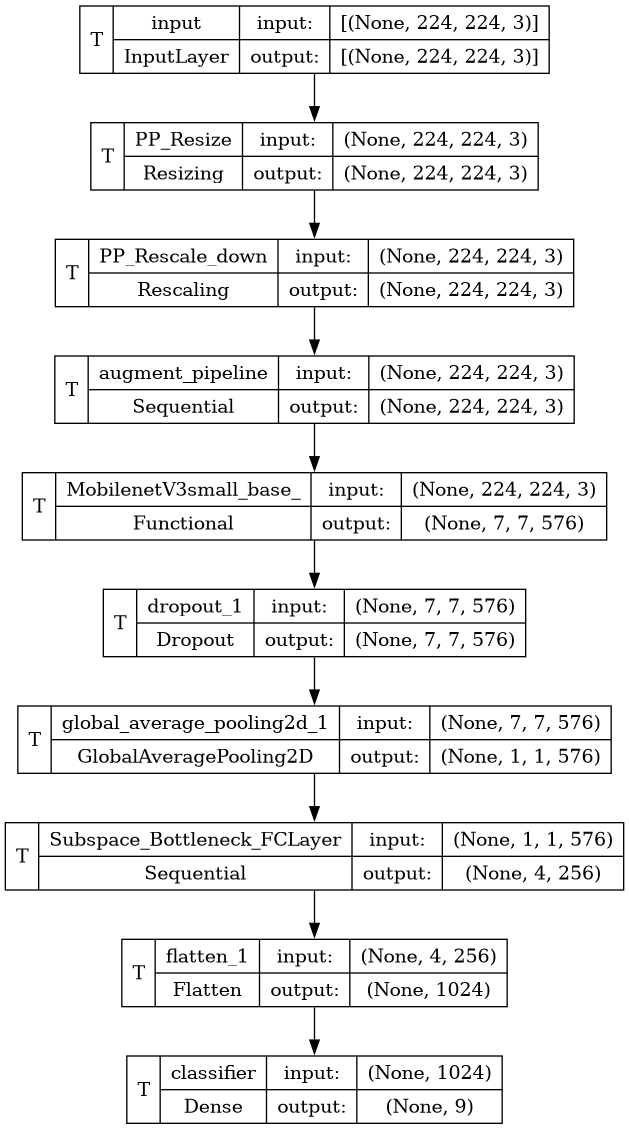

In [20]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [21]:
from tensorflow.keras.optimizers import Adam, AdamW

checkpoint = tf.keras.callbacks.ModelCheckpoint(f"base_{MODEL_NAME}", save_best_only=True, monitor=ES_MONITOR)
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1)
    metrics = [] if isTPU else ['accuracy'] 
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

    def createWarmUpScheduler(epochs=5, inc_rate=0.5, init_lr=2e-6, final_lr=2e-5):
        def scheduler(e, lr):
            if e < epochs:
                new_lr =  lr + (lr * inc_rate)
                return new_lr if new_lr < final_lr else final_lr
            elif e == epochs:
                return final_lr
            else:
                return lr

        return scheduler
        
    warmup = keras.callbacks.LearningRateScheduler(createWarmUpScheduler(WARMUP_EPOCHS, WARMUP_INCREMENT_RATE, WARMUP_INIT_LR, INIT_LR1))

    callbacks = [checkpoint, early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])
    print(len(callbacks))

print(model.optimizer.get_config())

3
{'name': 'AdamW', 'weight_decay': 0.05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 0.0002, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2025-07-05 06:42:00.282013: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1751697725.807682      65 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


329/329 [==============================] - 57s 82ms/step - loss: 28.1675 - accuracy: 0.5640 - val_loss: 5.3807 - val_accuracy: 0.6631 - lr: 2.0000e-04
Epoch 2/300
329/329 [==============================] - 24s 73ms/step - loss: 1.1027 - accuracy: 0.5841 - val_loss: 0.2761 - val_accuracy: 0.6426 - lr: 2.0000e-04
Epoch 3/300
329/329 [==============================] - 24s 73ms/step - loss: 0.2460 - accuracy: 0.6622 - val_loss: 0.1922 - val_accuracy: 0.7439 - lr: 2.0000e-04
Epoch 4/300
329/329 [==============================] - 24s 74ms/step - loss: 0.1923 - accuracy: 0.7270 - val_loss: 0.1594 - val_accuracy: 0.7776 - lr: 2.0000e-04
Epoch 5/300
329/329 [==============================] - 24s 73ms/step - loss: 0.1669 - accuracy: 0.7592 - val_loss: 0.1360 - val_accuracy: 0.8242 - lr: 2.0000e-04
Epoch 6/300
329/329 [==============================] - 24s 73ms/step - loss: 0.1448 - accuracy: 0.7864 - val_loss: 0.1286 - val_accuracy: 0.8273 - lr: 2.0000e-04
Epoch 7/300
329/329 [==================

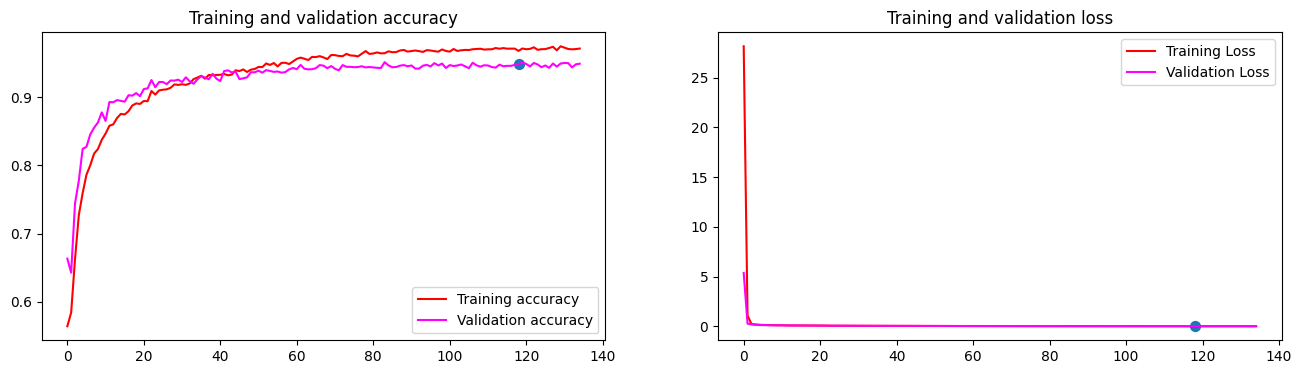

CPU times: user 1h 47min, sys: 8min 2s, total: 1h 55min 3s
Wall time: 53min 50s


In [22]:
%%time

# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=callbacks,
    )

# Plot training results
plot_loss_acc(history1.history)

# Evaluations #1A

Validation Set Stats
model.evaluate
110/110 [==============================] - 3s 22ms/step - loss: 0.0221 - accuracy: 0.9509
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.89302   0.85333   0.87273       225
       Lantana    0.91743   0.93897   0.92807       213
   Parkinsonia    0.96569   0.95631   0.96098       206
    Parthenium    0.95192   0.96585   0.95884       205
Prickly acacia    0.90698   0.91549   0.91121       213
   Rubber vine    0.91707   0.93069   0.92383       202
     Siam weed    0.97044   0.91628   0.94258       215
    Snake weed    0.89848   0.87192   0.88500       203
      Negative    0.95974   0.96870   0.96420      1821

      accuracy                        0.94433      3503
     macro avg    0.93120   0.92417   0.92749      3503
  weighted avg    0.94421   0.94433   0.94416      3503


                False Positive Rate  Accuracy
Chinee apple               0.007016  0.853333
Lantana                    0.005471  0.938967
Parkinsonia                0.002123  0.956311
Parthenium                 0.003032  0.965854
Prickly acacia    

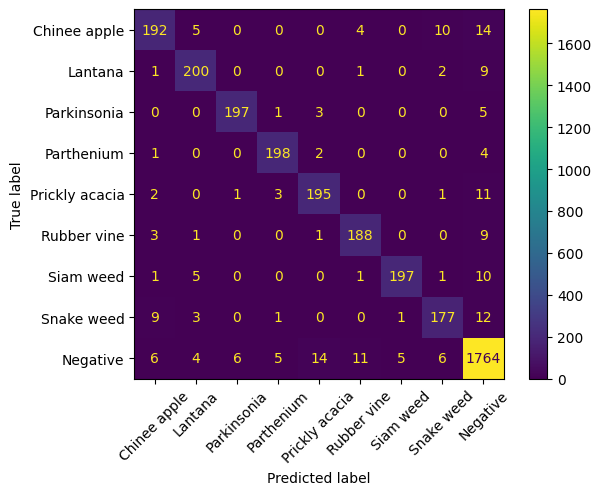

Test Set Stats
model.evaluate
110/110 [==============================] - 3s 24ms/step - loss: 0.6515 - accuracy: 0.4683
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.12030   0.07111   0.08939       225
       Lantana    0.10959   0.03774   0.05614       212
   Parkinsonia    0.25000   0.05340   0.08800       206
    Parthenium    0.16667   0.04412   0.06977       204
Prickly acacia    0.21429   0.02830   0.05000       212
   Rubber vine    0.11111   0.03980   0.05861       201
     Siam weed    0.14607   0.06075   0.08581       214
    Snake weed    0.11667   0.03448   0.05323       203
      Negative    0.52971   0.85667   0.65464      1821

      accuracy                        0.46827      3498
     macro avg    0.19604   0.13626   0.13395      3498
  weighted avg    0.34966   0.46827   0.37393      3498


                False Positive Rate  Accuracy
Chinee apple               0.035747  0.071111
Lantana                    0.019781  0.037736
Parkinsonia                0.010024  0.053398
Parthenium                 0.013661  0.044118
Prickly acacia    

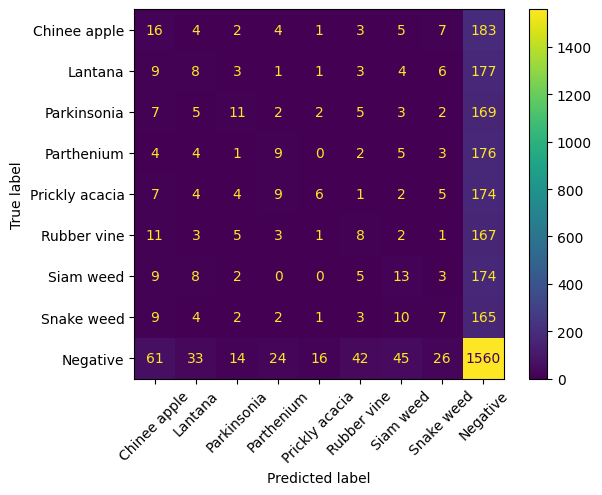

In [23]:
print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")   
a, b = eval_model(model, test_generator)

# Freezing Base Model

In [24]:
with strategy.scope():
    for layer in model.layers:
        if 'base' in layer.name.lower():
            print("Freezing layer", layer.name, layer.trainable)
            layer.trainable = False

Freezing layer MobilenetV3small_base_ True


# Evaluations #1B

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 23ms/step - loss: 0.0057 - accuracy: 0.9913
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    1.00000   0.99556   0.99778       676
       Lantana    0.99687   1.00000   0.99844       638
   Parkinsonia    0.99040   1.00000   0.99518       619
    Parthenium    0.98553   1.00000   0.99271       613
Prickly acacia    0.99683   0.98744   0.99211       637
   Rubber vine    0.99671   0.99835   0.99753       606
     Siam weed    0.99845   1.00000   0.99923       645
    Snake weed    0.99183   0.99508   0.99345       610
      Negative    0.99872   0.99652   0.99762      5464

      accuracy                        0.99676     10508
     macro avg    0.99504   0.99700   0.99600     10508
  weighted avg    0.99678   0.99676   0.99677     10508


                False Positive Rate  Accuracy
Chinee apple               0.000000  0.995562
Lantana                    0.000203  1.000000
Parkinsonia                0.000607  1.000000
Parthenium                 0.000910  1.000000
Prickly acacia    

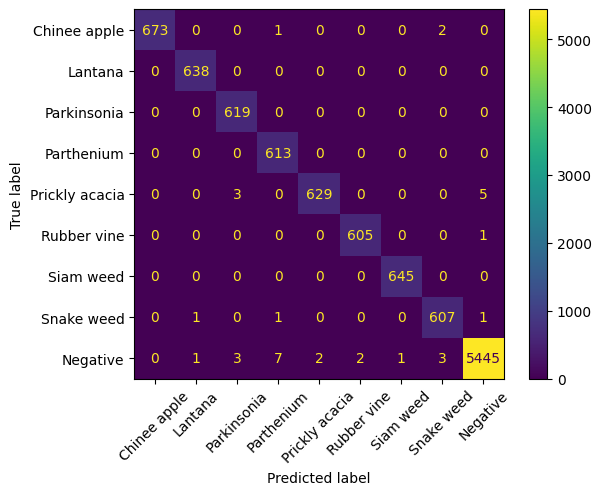

Validation Set Stats
model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.0220 - accuracy: 0.9483
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92488   0.87556   0.89954       225
       Lantana    0.93953   0.94836   0.94393       213
   Parkinsonia    0.96190   0.98058   0.97115       206
    Parthenium    0.90625   0.99024   0.94639       205
Prickly acacia    0.94258   0.92488   0.93365       213
   Rubber vine    0.95960   0.94059   0.95000       202
     Siam weed    0.97101   0.93488   0.95261       215
    Snake weed    0.90816   0.87685   0.89223       203
      Negative    0.96723   0.97254   0.96988      1821

      accuracy                        0.95375      3503
     macro avg    0.94235   0.93828   0.93993      3503
  weighted avg    0.95382   0.95375   0.95357      3503


                False Positive Rate  Accuracy
Chinee apple               0.004881  0.875556
Lantana                    0.003951  0.948357
Parkinsonia                0.002426  0.980583
Parthenium                 0.006367  0.990244
Prickly acacia    

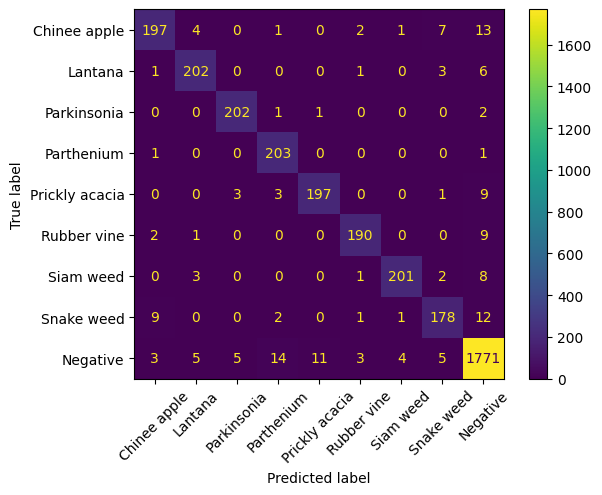

Test Set Stats
model.evaluate
110/110 [==============================] - 3s 25ms/step - loss: 0.6515 - accuracy: 0.4683
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93204   0.85333   0.89095       225
       Lantana    0.96635   0.94811   0.95714       212
   Parkinsonia    0.96667   0.98544   0.97596       206
    Parthenium    0.95588   0.95588   0.95588       204
Prickly acacia    0.94712   0.92925   0.93810       212
   Rubber vine    0.96078   0.97512   0.96790       201
     Siam weed    0.96078   0.91589   0.93780       214
    Snake weed    0.88780   0.89655   0.89216       203
      Negative    0.96376   0.97858   0.97112      1821

      accuracy                        0.95597      3498
     macro avg    0.94902   0.93757   0.94300      3498
  weighted avg    0.95582   0.95597   0.95570      3498


                False Positive Rate  Accuracy
Chinee apple               0.004277  0.853333
Lantana                    0.002130  0.948113
Parkinsonia                0.002126  0.985437
Parthenium                 0.002732  0.955882
Prickly acacia    

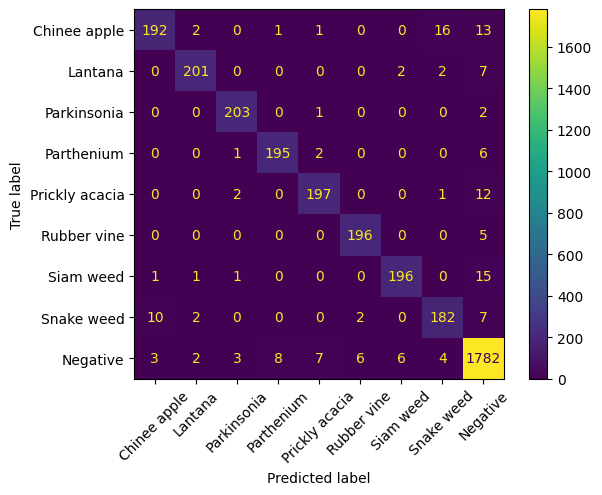

In [25]:
## Test After Freezing
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")   
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.85652   0.87556   0.86593       225
       Lantana    0.84082   0.97170   0.90153       212
   Parkinsonia    0.96667   0.98544   0.97596       206
    Parthenium    0.95588   0.95588   0.95588       204
Prickly acacia    0.87395   0.98113   0.92444       212
   Rubber vine    0.95588   0.97015   0.96296       201
     Siam weed    0.95610   0.91589   0.93556       214
    Snake weed    0.88780   0.89655   0.89216       203
      Negative    0.97553   0.94124   0.95808      1821

      accuracy                        0.94225      3498
     macro avg    0.91879   0.94373   0.93028      3498
  weighted avg    0.94448   0.94225   0.94269      3498


                False Positive Rate  Accuracy
Chinee apple               0.010082  0.875556
Lantana                    0.011869  0.971698
Parkinsonia                0.002126  0.985437
Parthenium                 0.002732  0.955882
Prickly acacia    

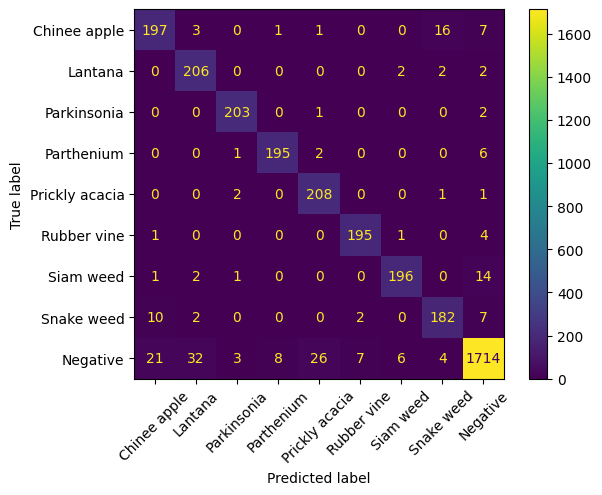

In [26]:
printStats(a,b,0.11)

# Trial 2

In [27]:
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=INIT_LR2,  weight_decay=W_DECAY2, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2)
    metrics = [] if isTPU else ['accuracy']
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=ES_MONITOR, factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR2)


print(model.optimizer.get_config())

{'name': 'AdamW', 'weight_decay': 0.0005, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 2e-06, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2025-07-05 07:40:04.054784: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 17s 39ms/step - loss: 0.0184 - accuracy: 0.9490 - val_loss: 0.0197 - val_accuracy: 0.9546 - lr: 2.0000e-06
Epoch 2/300
329/329 [==============================] - 11s 34ms/step - loss: 0.0175 - accuracy: 0.9510 - val_loss: 0.0197 - val_accuracy: 0.9552 - lr: 2.0000e-06
Epoch 3/300
329/329 [==============================] - 12s 37ms/step - loss: 0.0169 - accuracy: 0.9529 - val_loss: 0.0196 - val_accuracy: 0.9552 - lr: 2.0000e-06
Epoch 4/300
327/329 [============================>.] - ETA: 0s - loss: 0.0173 - accuracy: 0.9535
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999959603884e-06.
329/329 [==============================] - 12s 35ms/step - loss: 0.0173 - accuracy: 0.9536 - val_loss: 0.0197 - val_accuracy: 0.9549 - lr: 2.0000e-06
Epoch 5/300
329/329 [==============================] - 11s 34ms/step - loss: 0.0167 - accuracy: 0.9533 - val_loss: 0.0196 - val_accuracy: 0.9558 - lr: 1.6000e-06
Epoch 6/300
329/329 [===================

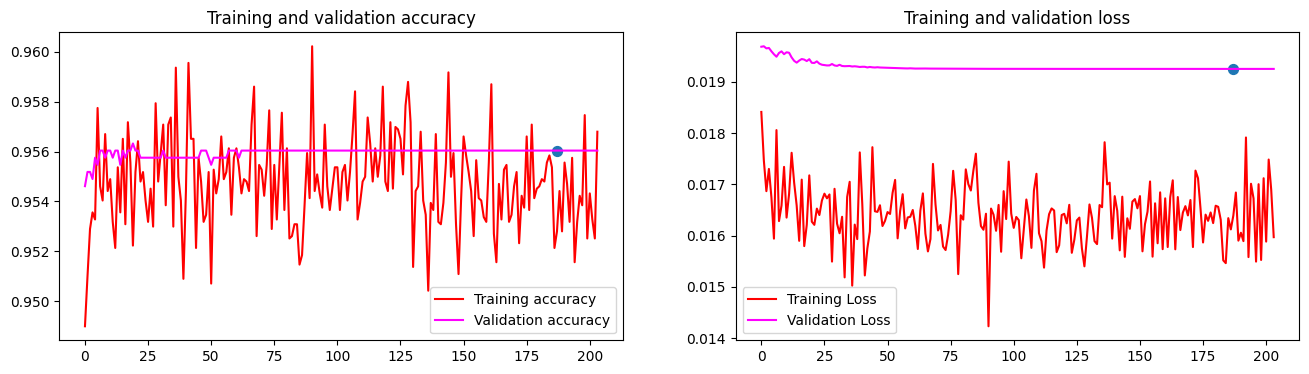

CPU times: user 1h 49min 19s, sys: 11min 21s, total: 2h 40s
Wall time: 41min 5s


In [28]:
%%time

# Train the model
history2 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr]
    )

print("Saving the Checkpoint")
model.save(MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)


# Accuracy / Loss Plots

Total Epochs: range(0, 339)


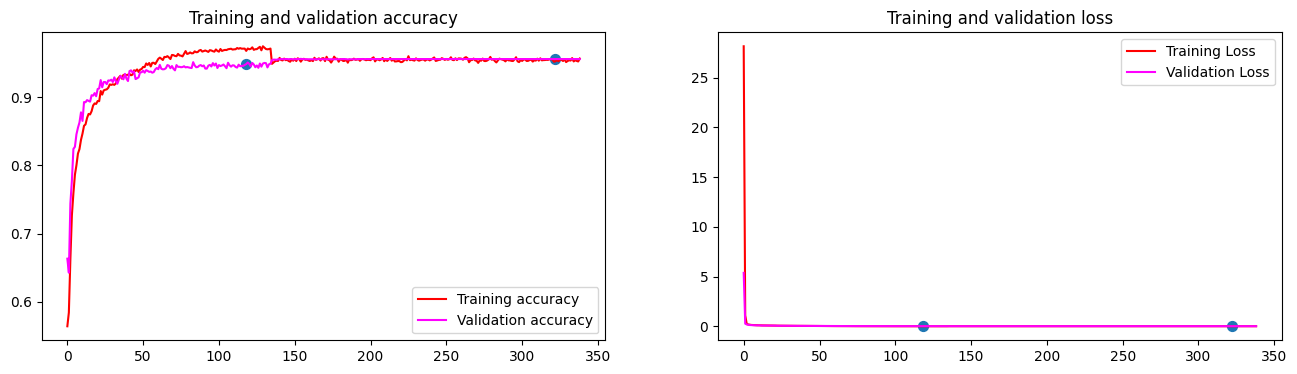

In [29]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 135)


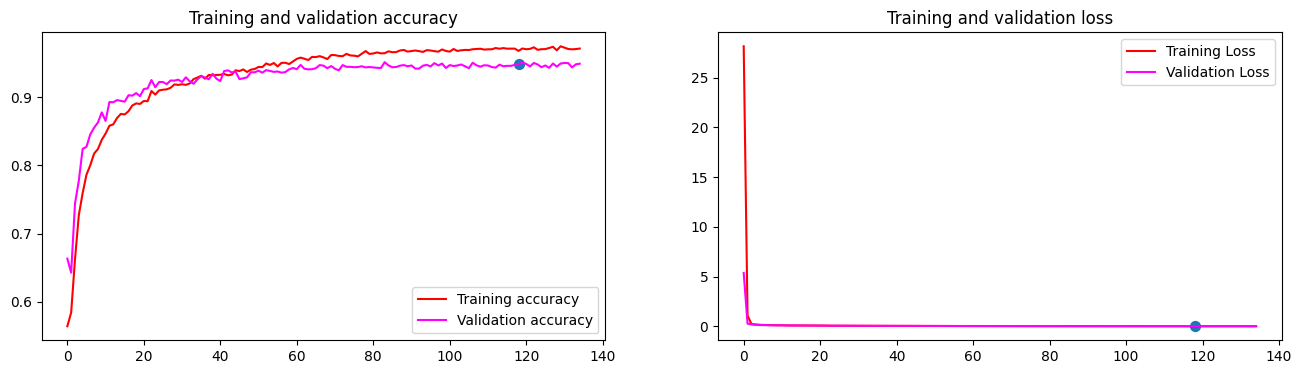

Total Epochs: range(0, 204)


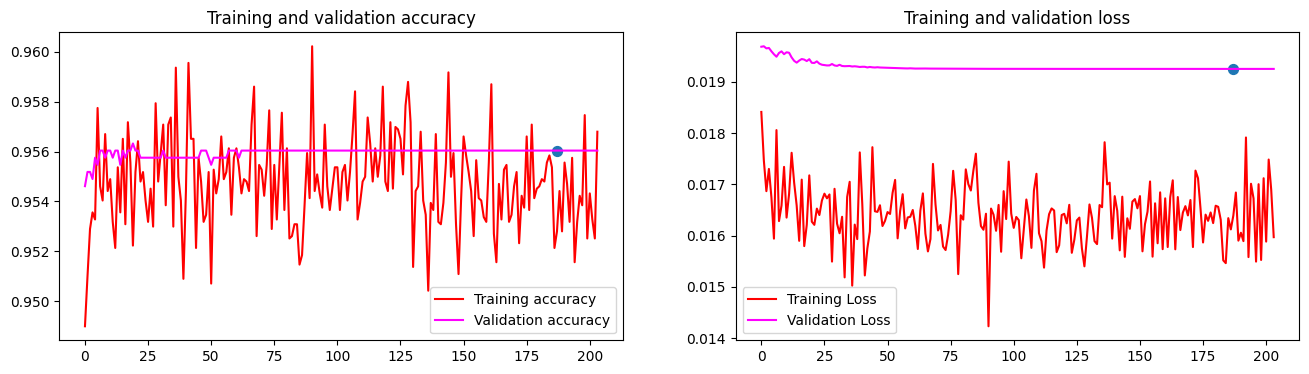

In [30]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 [==============================] - 7s 21ms/step - loss: 0.0036 - accuracy: 0.9962
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    1.00000   0.98669   0.99330       676
       Lantana    0.99687   1.00000   0.99844       638
   Parkinsonia    0.99199   1.00000   0.99598       619
    Parthenium    0.99031   1.00000   0.99513       613
Prickly acacia    0.99683   0.98744   0.99211       637
   Rubber vine    0.99671   1.00000   0.99835       606
     Siam weed    0.99537   1.00000   0.99768       645
    Snake weed    0.97749   0.99672   0.98701       610
      Negative    0.99890   0.99616   0.99753      5464

      accuracy                        0.99619     10508
     macro avg    0.99383   0.99633   0.99506     10508
  weighted avg    0.99623   0.99619   0.99620     10508


                False Positive Rate  Accuracy
Chinee apple               0.000000  0.986686
Lantana                    0.000203  1.000000
Parkinsonia                0.000506  1.000000
Parthenium                 0.000606  1.000000
Prickly acacia    

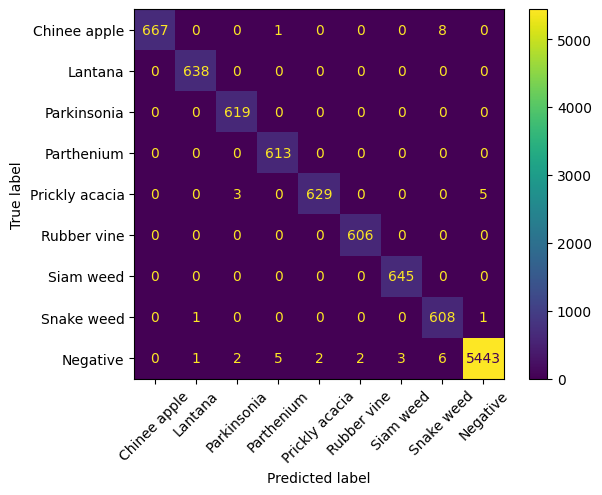


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 21ms/step - loss: 0.0192 - accuracy: 0.9560
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93659   0.85333   0.89302       225
       Lantana    0.93519   0.94836   0.94172       213
   Parkinsonia    0.96190   0.98058   0.97115       206
    Parthenium    0.94811   0.98049   0.96403       205
Prickly acacia    0.94258   0.92488   0.93365       213
   Rubber vine    0.94554   0.94554   0.94554       202
     Siam weed    0.96209   0.94419   0.95305       215
    Snake weed    0.88889   0.90640   0.89756       203
      Negative    0.97051   0.97584   0.97317      1821

      accuracy                        0.95604      3503
     macro avg    0.94349   0.93996   0.94143      3503
  weighted avg    0.95598   0.95604   0.95584      3503


                False Positive Rate  Accuracy
Chinee apple               0.003966  0.853333
Lantana                    0.004255  0.948357
Parkinsonia                0.002426  0.980583
Parthenium                 0.003335  0.980488
Prickly acacia    

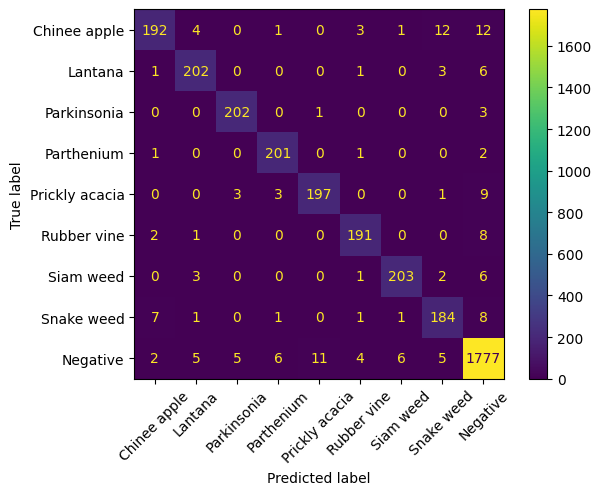


Testn Set Statistics
model.evaluate
110/110 [==============================] - 3s 22ms/step - loss: 0.0179 - accuracy: 0.9565
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.94924   0.83111   0.88626       225
       Lantana    0.96190   0.95283   0.95735       212
   Parkinsonia    0.97129   0.98544   0.97831       206
    Parthenium    0.97970   0.94608   0.96259       204
Prickly acacia    0.94712   0.92925   0.93810       212
   Rubber vine    0.95146   0.97512   0.96314       201
     Siam weed    0.93519   0.94393   0.93953       214
    Snake weed    0.85520   0.93103   0.89151       203
      Negative    0.96892   0.97584   0.97237      1821

      accuracy                        0.95655      3498
     macro avg    0.94667   0.94118   0.94324      3498
  weighted avg    0.95701   0.95655   0.95639      3498


                False Positive Rate  Accuracy
Chinee apple               0.003055  0.831111
Lantana                    0.002435  0.952830
Parkinsonia                0.001823  0.985437
Parthenium                 0.001214  0.946078
Prickly acacia    

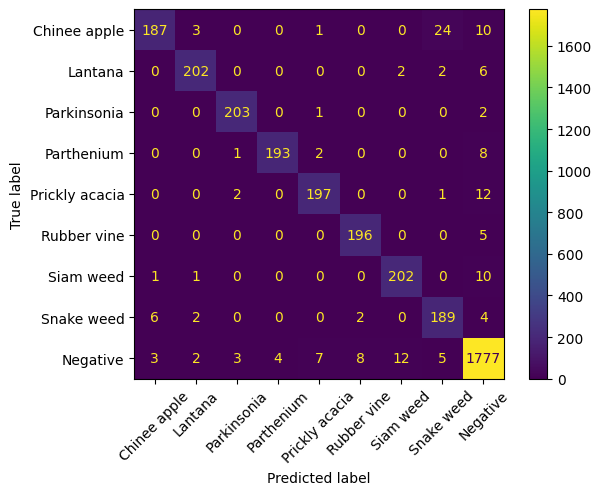

In [31]:
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.86425   0.84889   0.85650       225
       Lantana    0.83065   0.97170   0.89565       212
   Parkinsonia    0.97129   0.98544   0.97831       206
    Parthenium    0.97970   0.94608   0.96259       204
Prickly acacia    0.87395   0.98113   0.92444       212
   Rubber vine    0.94660   0.97015   0.95823       201
     Siam weed    0.92661   0.94393   0.93519       214
    Snake weed    0.85520   0.93103   0.89151       203
      Negative    0.97989   0.93630   0.95760      1821

      accuracy                        0.94111      3498
     macro avg    0.91424   0.94607   0.92889      3498
  weighted avg    0.94406   0.94111   0.94167      3498


                False Positive Rate  Accuracy
Chinee apple               0.009166  0.848889
Lantana                    0.012781  0.971698
Parkinsonia                0.001823  0.985437
Parthenium                 0.001214  0.946078
Prickly acacia    

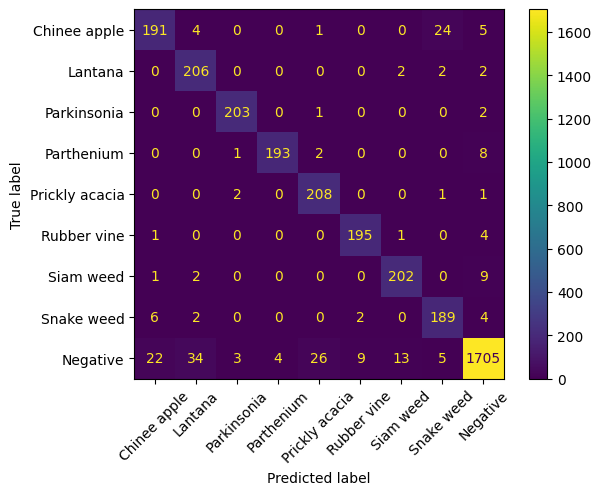

In [32]:
printStats(a,b,0.11)

## Clear Files

In [33]:
shutil.rmtree(base_dir)